**ML COURSE 2025-2026**
# RECAP LAB

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm import trange
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from utils import stratified_train_test_split, accuracy

In [2]:
# data loading and preprocessing
data = pd.read_csv('ML_resources/iris.csv')
display(data.head())

feature_names = data.columns[:-1]
target_col = 'species'

X = data.drop(target_col, axis=1).to_numpy()
y = data[target_col].to_numpy()

print("X.shape_", X.shape, "y.shape_", y.shape)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


X.shape_ (150, 4) y.shape_ (150,)


## K-fold Cross-Validation



We use cross-validation when we want to have an estimate of the performance of our model, and we do not want the testing to be affected by the specific training-test split we chose.

In **K-fold cross-validation**, the dataset is divided into *K* equal-sized subsets, or "folds". The process works as follows:

1. For each iteration, one fold is held out as the test set.
2. The model is trained on the remaining *K - 1* folds.
3. The trained model is evaluated on the test fold.
4. This process is repeated *K* times, with each fold used exactly once for testing.

The final performance metric is the average of the metrics obtained from all *K* iterations. After evaluation, a final model is typically trained on the full dataset for use in real-world predictions.

Cross-validation can be performed with almost any model we have studied. 

The only caveat is to watch out for high computation times when using more complex models, such as XGBoost or neural networks.

![cross_validation.png](figures/cross_validation.png)


### Example with scikit-learn

In [3]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier


# Set up cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=0)       #shuffle serve a mescolare i dati prima di dividerli in fold, per evitare che fold contengano solo campioni di una classe
accuracies = []

for train_index, test_index in kf.split(X): # kf.split(X) returns the indices of the training and test sets
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # istantiate the decision tree classifier
    tree = DecisionTreeClassifier(max_depth=3, min_impurity_decrease=0.0, random_state=0)
    tree.fit(X_train, y_train)
    
    # Predict on the validation fold
    y_pred = tree.predict(X_test)
    
    # Evaluate accuracy
    acc = accuracy(y_test, y_pred)
    accuracies.append(acc)
    print(f"Fold accuracy: {acc:.4f}")

# Report average performance
print(f"\nAverage cross-validation accuracy: {np.mean(accuracies):.4f}")


Fold accuracy: 0.9667
Fold accuracy: 0.9000
Fold accuracy: 1.0000
Fold accuracy: 0.9667
Fold accuracy: 0.9333

Average cross-validation accuracy: 0.9533


### Example without scikit-learn

In [4]:
import numpy as np

# General fold generator function
def get_folds(X, y, n_splits=5, seed=0):
    np.random.seed(seed)
    # shuffle the indices
    indices = np.random.permutation(len(X))

    # create the folds
    total_samples = len(X)
    # size of all folds if the dataset is divisible by n_splits
    base_fold_size = total_samples // n_splits
    # if total_samples is not divisible by n_splits, we need to handle the remainder
    remainder = total_samples % n_splits

    fold_sizes = []
    for i in range(n_splits):
        # distribute the remainder across the first few folds
        # e.g. if n_splits=3 and total_samples=10, then base_fold_size=3 and remainder=1, fold_sizes = [4,3,3]
        fold_sizes.append(base_fold_size + (1 if i < remainder else 0))
    
    #initialize the vecotr containing the indices of the folds
    current = 0
    folds = []
    for size in fold_sizes:
        start, stop = current, current + size
        folds.append(indices[start:stop])
        current = stop

    return folds

# Cross-validation using the get_folds function
def cross_val(X, y, n_splits=5, seed=0):
    folds = get_folds(X, y, n_splits=n_splits, seed=seed)
    accuracies = []

    for i in range(n_splits):
        # initialize the test set
        test_idx = folds[i]
        # initialize the training set (union of all the other folds)
        train_idx = np.hstack([folds[j] for j in range(n_splits) if j != i])

        # split the data into training and test sets
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Train the tree on the training fold
        tree = DecisionTreeClassifier(max_depth=3, min_impurity_decrease=0.0, random_state=0)
        tree.fit(X_train, y_train)

        # Predict on the validation fold
        y_pred = tree.predict(X_test)

        # Evaluate accuracy
        acc = accuracy(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold {i+1} accuracy: {acc:.4f}")

    print(f"\nAverage cross-validation accuracy: {np.mean(accuracies):.4f}")
    return accuracies


# test
accuracies = cross_val(X, y, n_splits=5, seed=0)


Fold 1 accuracy: 0.9667
Fold 2 accuracy: 0.9000
Fold 3 accuracy: 1.0000
Fold 4 accuracy: 0.9667
Fold 5 accuracy: 0.9333

Average cross-validation accuracy: 0.9533


NOTE: Using cross-validation on a decision tree is different from training a random forest. With cross-validation, we are not building a model with stronger generalization capabilities, we are simply obtaining a more robust estimate of the performance of a single decision tree model.
In contrast, a random forest combines many decision trees to create a new model that typically generalizes better to unseen data by reducing variance through averaging.

## Nested Cross-Validation


Let's see it on decision trees!

### With scikit-learn

In [5]:
from sklearn.model_selection import KFold
from itertools import product
import numpy as np

def nested_cross_val_sklearn(X, y, cat_features_idx, 
                     outer_splits=5, inner_splits=3,
                     param_grid={'max_depth': [2, 3, 4], 'min_impurity_improvement': [0.0, 0.01]}):

    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=42)
    outer_scores = []
    best_params_list = []

    # Extract hyperparameter names and values
    param_names = list(param_grid.keys())
    param_values_lists = [param_grid[name] for name in param_names]

    # Generate all combinations manually (supports up to 2 hyperparameters for simplicity)
    param_combinations = []
    for val1 in param_values_lists[0]:
        for val2 in param_values_lists[1]:
            param_combinations.append((val1, val2))

    for train_val_idx, test_idx in outer_cv.split(X): #outer_cv.split(X) returns the indices of the training and test sets
        X_train_val, X_test = X[train_val_idx], X[test_idx]
        y_train_val, y_test = y[train_val_idx], y[test_idx]

        # Inner loop for hyperparameter tuning
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=42)
        inner_scores = []

        # consider all possible combinations of hyperparameters and train K models using these hyperparameters
        for param_values in param_combinations: # param_values is a tuple of (max_depth, min_impurity_improvement)
            avg_val_score = 0

            for inner_train_idx, inner_val_idx in inner_cv.split(X_train_val): #inner_cv.split(X_train_val) returns the indices of the training and test sets
                X_inner_train, X_inner_val = X_train_val[inner_train_idx], X_train_val[inner_val_idx]
                y_inner_train, y_inner_val = y_train_val[inner_train_idx], y_train_val[inner_val_idx]

                # Train the model with the current hyperparameters
                tree = DecisionTreeClassifier(max_depth=param_values[0], min_impurity_decrease=param_values[1], random_state=42)
                tree.fit(X_inner_train, y_inner_train)
                y_pred = tree.predict(X_inner_val)
                # Evaluate accuracy
                score = accuracy(y_inner_val, y_pred)
                # Accumulate the score (of this combination of hyperparameters)
                avg_val_score += score
            # Average the score over inner folds
            avg_val_score /= inner_splits
            # we save a tuple containing the average score and the hyperparameters
            inner_scores.append((avg_val_score, param_values))

        # Choose best parameters from inner loop
        best_inner_score, best_params = max(inner_scores, key=lambda x: x[0])
        best_params_list.append(best_params)

        # Retrain on the full train+val set with best params
        final_tree = DecisionTreeClassifier(max_depth=best_params[0], min_impurity_decrease=best_params[1], random_state=42)
        final_tree.fit(X_train_val, y_train_val)
        final_predictions = final_tree.predict(X_test)
        test_score = accuracy(y_test, final_predictions)
        outer_scores.append(test_score)

    print(f"Average accuracy across outer folds: {np.mean(outer_scores):.4f}")
    print("Best params for each fold:")
    for i, params in enumerate(best_params_list):
        param_dict = {name: val for name, val in zip(param_names, params)}
        print(f" Fold {i+1}: {param_dict}")

    return np.mean(outer_scores), best_params_list

In [6]:
train_accuracy, best_params = nested_cross_val_sklearn(
    X, y,
    cat_features_idx=[],
    outer_splits=10,
    inner_splits=3,
    param_grid={'max_depth': [2, 3, 4], 'min_impurity_improvement': [0.0, 0.01]}
)

Average accuracy across outer folds: 0.9400
Best params for each fold:
 Fold 1: {'max_depth': 4, 'min_impurity_improvement': 0.0}
 Fold 2: {'max_depth': 4, 'min_impurity_improvement': 0.0}
 Fold 3: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 4: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 5: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 6: {'max_depth': 4, 'min_impurity_improvement': 0.0}
 Fold 7: {'max_depth': 2, 'min_impurity_improvement': 0.0}
 Fold 8: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 9: {'max_depth': 2, 'min_impurity_improvement': 0.0}
 Fold 10: {'max_depth': 3, 'min_impurity_improvement': 0.0}


### Without scikit-learn

In [7]:
import numpy as np
from itertools import product

def get_folds(X, y, n_splits=6, seed=0):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    
    total_samples = len(X)
    base_fold_size = total_samples // n_splits
    remainder = total_samples % n_splits

    fold_sizes = []
    for i in range(n_splits):
        fold_sizes.append(base_fold_size + (1 if i < remainder else 0))

    current = 0
    folds = []
    for size in fold_sizes:
        start, stop = current, current + size
        folds.append(indices[start:stop])
        current = stop
    return folds

def nested_cross_val(X, y, cat_features_idx, 
                     outer_splits=5, inner_splits=3,
                     param_grid={'max_depth': [2, 3, 4], 'min_impurity_improvement': [0.0, 0.01]}):

    outer_folds = get_folds(X, y, n_splits=outer_splits, seed=0)
    outer_scores = []
    best_params_list = []

    # Generate all combinations of hyperparameters
    param_combinations = list(product(*param_grid.values()))
    param_names = list(param_grid.keys())

    for i, test_idx in enumerate(outer_folds):
        train_val_idx = np.hstack([fold for j, fold in enumerate(outer_folds) if j != i])
        X_train_val, X_test = X[train_val_idx], X[test_idx]
        y_train_val, y_test = y[train_val_idx], y[test_idx]

        # Inner loop for hyperparameter tuning
        inner_folds = get_folds(X_train_val, y_train_val, n_splits=inner_splits, seed=0)
        inner_scores = []

        for param_values in param_combinations:
            avg_val_score = 0

            for k, val_idx in enumerate(inner_folds):
                train_idx = np.hstack([fold for j, fold in enumerate(inner_folds) if j != k])
                X_inner_train, X_inner_val = X_train_val[train_idx], X_train_val[val_idx]
                y_inner_train, y_inner_val = y_train_val[train_idx], y_train_val[val_idx]


                tree = DecisionTreeClassifier(max_depth=param_values[0], min_impurity_decrease=param_values[1], random_state=42)
                tree.fit(X_inner_train, y_inner_train)
                y_pred = tree.predict(X_inner_val)
                score = accuracy(y_inner_val, y_pred)
                avg_val_score += score

            avg_val_score /= inner_splits
            inner_scores.append((avg_val_score, param_values))

        # Choose best parameters from inner loop
        # max returns the tuple with the highest score (key=lambda x: x[0] means "use the first element of the tuple as the key for comparison")
        best_inner_score, best_params = max(inner_scores, key=lambda x: x[0]) 
        best_params_list.append(best_params)

        # Retrain on the full train+val set with best params
        final_tree = DecisionTreeClassifier(max_depth=best_params[0], min_impurity_decrease=best_params[1], random_state=42)
        final_tree.fit(X_train_val, y_train_val)
        # Predict on the test fold
        final_predictions = final_tree.predict(X_test)
        test_score = accuracy(y_test, final_predictions)
        # Evaluate accuracy
        outer_scores.append(test_score)

    # Report average performance
    print(f"Average accuracy across outer folds: {np.mean(outer_scores):.4f}")
    print("Best params for each fold:")
    for i, params in enumerate(best_params_list):
        param_dict = {name: val for name, val in zip(param_names, params)}
        print(f" Fold {i+1}: {param_dict}")

    return np.mean(outer_scores), best_params_list


In [8]:
train_accuracy, best_params = nested_cross_val(
    X, y,
    cat_features_idx=[],
    outer_splits=10,
    inner_splits=3,
    param_grid={'max_depth': [2, 3, 4], 'min_impurity_improvement': [0.0, 0.01]}
)

Average accuracy across outer folds: 0.9333
Best params for each fold:
 Fold 1: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 2: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 3: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 4: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 5: {'max_depth': 4, 'min_impurity_improvement': 0.0}
 Fold 6: {'max_depth': 4, 'min_impurity_improvement': 0.0}
 Fold 7: {'max_depth': 2, 'min_impurity_improvement': 0.0}
 Fold 8: {'max_depth': 3, 'min_impurity_improvement': 0.0}
 Fold 9: {'max_depth': 2, 'min_impurity_improvement': 0.0}
 Fold 10: {'max_depth': 3, 'min_impurity_improvement': 0.0}



We use **nested cross-validation** when the training process involves **hyperparameter tuning**, hence choosing the hyperparameters (e.g., the regularization strength) that yield the best model performance.

In addition to selecting optimal hyperparameters, we also want a **reliable estimate of the model’s generalization performance** (as before). A straightforward strategy might be to split the dataset into **training**, **validation**, and **test** sets: we tune hyperparameters on the validation set and evaluate final performance on the test set. However, this approach is sensitive to how the data is split.

To address this, **nested cross-validation** uses a two-loop structure:

- The **inner loop** performs hyperparameter tuning using cross-validation. For each set of hyperparameters, the model is trained and validated across *K* different splits of the training data.
- The **outer loop** evaluates the model’s generalization performance. For each outer split, the inner loop selects the best hyperparameters on the training portion, and the resulting model is tested on the outer test fold.

This two-tiered structure ensures that:
- **Hyperparameter tuning is done without peeking at the outer test data**, preventing overfitting.
- **Performance evaluation is based on multiple test folds**, giving a more robust estimate of generalization.

![llustration-of-the-nested-cross-validation](figures/llustration-of-the-nested-cross-validation.png)

After nested cross-validation is complete, we can retrain the model on the **entire dataset**, using the **most frequently selected hyperparameters** (e.g., the mode from the outer loop), to create the final model.

## Balanced Random Forest


Decision trees offer advantages in terms of interpretability and efficiency, but relying on a **single tree** can cause **high variance** and overfitting.

To address this, we build an **ensemble** of multiple decision trees, known as a **forest**. Instead of training just one tree, we train several trees on **slightly different versions** of the training dataset. At test time, we predict the class that receives the majority vote across all trees.

What does **slightly different versions** of the training dataset mean?
Each tree in the forest is trained on a **randomly sampled subset** of the training data. This randomness introduces diversity among the trees, reducing variance and improving generalization.


**⚖️ THE PROBLEM OF CLASS IMBALANCE:** in many real-world applications, datasets are imbalanced, meaning that some classes contain significantly more training samples that others (e.g., in rare disease detection, healthy patients largely outnumber affected patients).

In the presence of class imbalance, machine learning models tend to predict well the majority class and may largely ignore the minority class. This happens because because errors on the minority class contribute less to the overall loss function due to the small number of samples. As a result, the model can achieve high accuracy while performing poorly on the minority classn (that's why also proper metrics are key). 

🌲⚖️ **Balanced random forest**
Variation of random forest that balances the data used to train each decision tree in the forest. For each sample it undersample the majority class so that each tree gets a balanced dataset between the majority and minority classes. 

During bagging (bootstrap aggregation), we count the number of examples in the minority class and we sample (with replacement) this number for each target class.

In [9]:
from utils_noexam import DecisionTree
import pandas as pd

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,12.08,1.39,2.50,22.5,84.0,2.56,2.29,0.43,1.04,2.90,0.93,3.19,385.0,1
1,13.67,1.25,1.92,18.0,94.0,2.10,1.79,0.32,0.73,3.80,1.23,2.46,630.0,1
2,13.76,1.53,2.70,19.5,132.0,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235.0,0
3,12.72,1.75,2.28,22.5,84.0,1.38,1.76,0.48,1.63,3.30,0.88,2.42,488.0,1
4,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0


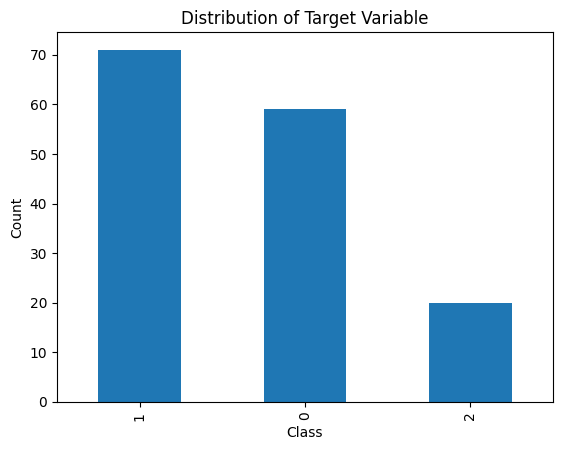

In [10]:
wine_imbalance = pd.read_csv('ML_resources/wine_imbalanced.csv')
display(wine_imbalance.head())
X, y = wine_imbalance.drop('target', axis=1).to_numpy(), wine_imbalance['target'].to_numpy()


# histogram of the target variable
wine_imbalance['target'].value_counts().plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Target Variable')
plt.show()


In [11]:
def balanced_bootstrap_sample(X, y):
    """
    Find number of samples in minority class. For each class, sample with 
    replacement the same number of samples as the minority class, to create a balanced dataset.
    Parameters
    ----------
    X: numpy array of shape (n_samples, n_features)
    y: numpy array of shape (n_samples,)
    """
    ...


def fit_balanced_random_forest(X, y, T, max_depth): 
    """Fit T trees using bagging"""
    # forest
    trees = []
    ... 
    return trees

def predict_balanced_random_forest(X, trees): 
    # get matrix of predictions of all trees of shape (num_trees, num_samples)
    tree_predictions = ... 

    # now, for each sample, we consider as final prediction the majority class among the predictions of all the trees.
    # we also compute a confidence score for each prediction, which is the proportion of trees that predicted the majority class.
    y_pred = []
    confidences = []
    # iterate through the columns (samples)
    for i in range(tree_predictions.shape[1]):                             
        # get the predictions of all trees for sample i
        ...
        # count how many times each class is predicted
        ...
        # get the class that appears most frequently
        ... 
        # compute confidence as the proportion of trees that predicted the majority class
        ... 
        # add the prediction to the prediction list
        ...
        # add the confidence to the confidence list
        ...
    return np.array(y_pred), np.array(confidences)


In [ ]:
from sklearn import datasets
from sklearn.utils import shuffle

# divide in train and test set stratified
X_train, X_test, y_train, y_test = ...

# Train and evaluate
trees = ...
y_pred, confidences = ...

# Accuracy may be not good metric under class imbalance
acc = ...
print(f"Balanced Random Forest Accuracy on Wine test set: {acc:.4f}")

# Confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = ... 
...

## Isolation Forest (alternative implementation)

- visualization of individual splits: step-by-step implementation
- implementation inside a function, not with a class
- note: dataset bootstrap uses replace=True
- exercise: with isolation forest we do not have labels

Let's visualize what we want to do step by step.

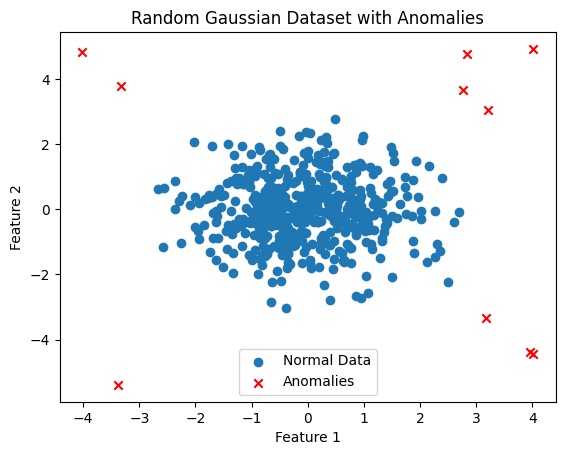

In [13]:
# First, create a dataset
np.random.seed(0) # for reproducibility

# random gaussian centered at (0,0) with std=1
X_normal = np.random.randn(500, 2)

np.random.seed(1) # for reproducibility

# Now we can add some anomalies, which are points that are far away from the rest of the data
n_anomalies = 10
X_anomalies = np.random.uniform(low=X_normal.max(), high=X_normal.max() + 3, size=(n_anomalies, 2))
X_anomalies *= np.random.choice([-1, 1], size=X_anomalies.shape)


# (just visualization... not important)
plt.scatter(X_normal[:, 0], X_normal[:, 1], label="Normal Data")
plt.scatter(X_anomalies[:, 0], X_anomalies[:, 1], color="red", label="Anomalies", marker="x")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Random Gaussian Dataset with Anomalies")
plt.legend()

np.random.seed(0) # for reproducibility

# the whole dataset contains both normal data and anomalies
X = np.vstack((X_normal, X_anomalies))
y = np.hstack((np.zeros(X_normal.shape[0]), np.ones(X_anomalies.shape[0])))

# now shuffle the dataset
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

The construnction of the isolation tree is an iterative procedure that: 
1. Split the dataset in 2 parts. 
    - We choose randomly a feature and randomly a threshold value
    - We send all the points with that feature value higher than the threshold to one side and the point with that feature value lower to the other side. 
    - This is equivalent to apply a linear separation boundary (a line in 2D, a hyperplane in higher dinmension)
2. Take each of the two subsets (which we call `left` and `right`) and repeat the process. 


During inference then: 
1. We send down the datapoint in the tree, applying the splits. 
2. We return the depth of the leaf where the point ends up. 

Remember: the procedure is unsupervised, we don't have labels when we build the tree. 

In [14]:
np.random.seed(0) # for reproducibility

# 1. Select a random feature: in this case we have 2 features 
feature_idx = np.random.randint(0, X.shape[1])
print("We select the feature:", feature_idx)

We select the feature: 0


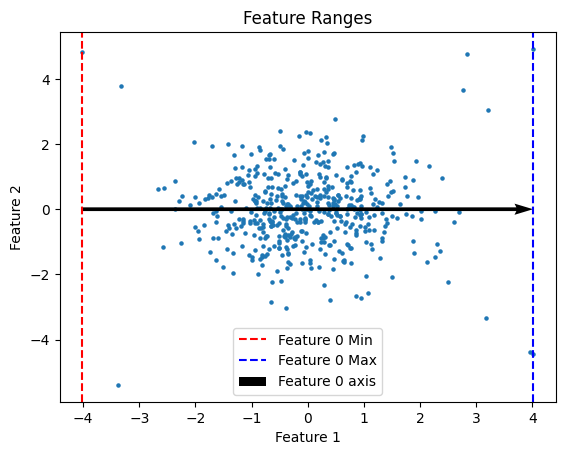

In [15]:
# 2. Select a random threshold.
# we need to select a value between the min and max of this features among the points. 


# 2a. find the min and the max of the feature
feature_value_min = X[:, feature_idx].min()
feature_value_max = X[:, feature_idx].max()

# (just visualization... not important)
plt.scatter(X[:, 0], X[:, 1], s=5)
plt.axvline(x=feature_value_min, color="red", linestyle="--", label=f"Feature {feature_idx} Min")
plt.axvline(x=feature_value_max, color="blue", linestyle="--", label=f"Feature {feature_idx} Max")
plt.quiver(feature_value_min, 0, feature_value_max - feature_value_min, 0, angles="xy", scale_units="xy", scale=1, color="black", label=f"Feature {feature_idx} axis")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Feature Ranges")
plt.legend()

We select the split value: 0.38905040338923236


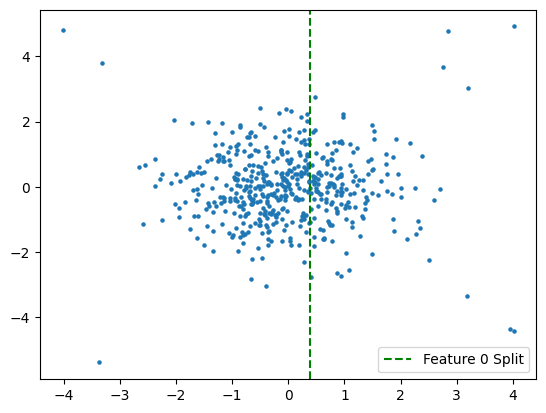

In [16]:
# 2b. inside the range we select a random value, which will be the plit point. 
# this will identify the line (or hyperplane) that will split the data in two parts. 
np.random.seed(0) # for reproducibility


feature_split_value = np.random.uniform(low=feature_value_min, high=feature_value_max)


# (just visualization... not important)
print("We select the split value:", feature_split_value)
plt.scatter(X[:, 0], X[:, 1], s=5)
plt.axvline(x=feature_split_value, color="green", linestyle="--", label=f"Feature {feature_idx} Split")
plt.legend()

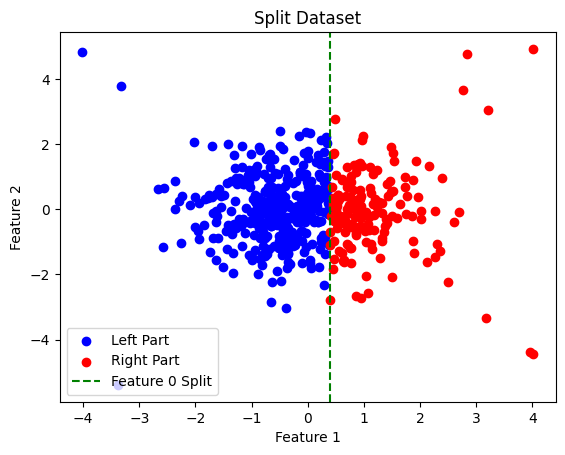

In [17]:
# 3. Split data into two parts: left and right. 
# now that we have a random line (or hyperplane), we use it to split the data into 2 parts
# that we call left and right 

X_left = X[X[:, feature_idx] <= feature_split_value]        # in left, we keep datapoints where the feature value is less or equal that the threshold 
X_right = X[X[:, feature_idx] > feature_split_value]        # in right, we keep datapoints where the feature value is greater than the threshold 

# (just visualization... not important)
plt.scatter(X_left[:, 0], X_left[:, 1], color="blue", label="Left Part")
plt.scatter(X_right[:, 0], X_right[:, 1], color="red", label="Right Part")
plt.axvline(x=feature_split_value, color="green", linestyle="--", label=f"Feature {feature_idx} Split")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Split Dataset")
plt.legend()

In [18]:
# 4. Now we repeat the procedure again for the two parts, X_left and X_right by treating them 
# as if they were the dataset to begin with. 
# Basically: X_left becomes the new X for the splitting function and the same for X_right.

Clearly it is handy to have a function that does this splitting, and in this case we will create the tree in an iterative way, so we will not use recursion, just to see a different approach than the one we used in LAB6.

**Note**: since we define a maximum depth after which we stop dividing the dataset, we need to add a correcting factor for the depth, which we call `c(n)`. It is the function that appears in the anomaly score formula (but with different n!). 

In [19]:
def c(n): 
    """ 
    Average depth of a tree with n_samples samples or equivalently
    average path length of an unsuccessful search in a BST.
    """
    if n <= 1:
        return 0 
    elif n == 2:
        return 1
    else:
        return 2 * (np.log(n-1) + np.euler_gamma - (n-1)/n)

Each split must be stored somehow, because during inference we need to send a new point down the tree according to the same splitting rules.

We store this information in an object called a 'Node'. 
And the structure of these node is the tree. 

The implementation is the following: we call the node of the Isolation Tree an `iNode` (isolation node) to distinguish it from the `Node` used in a Decision Tree.

In [20]:
from typing import Optional
@dataclass
class iNode: 
    feature: int | None         # Feature index for split, None for leaf
    threshold: float | None     # Threshold for split, None for leaf
    depth: int | float          # Depth of the node in the tree, float if corrected
    left_node: Optional["iNode"] = None  # Left child node
    right_node: Optional["iNode"] = None # Right child node
    is_leaf: bool = False       # True if leaf node

In [21]:
np.random.seed(0)  # for reproducibility

def build_tree(X_train, max_depth): 
    """
    Build an isolation tree (iTree) using iterative appraoch. 
    """
    # 1. Build an empty root node. 
    root = iNode(
        feature = None, 
        threshold = None, 
        depth = 0, 
        left_node = None, 
        right_node = None, 
        is_leaf = False 
    )

    # we use a queue to keep track of the nodes to process, we start with the root node and the whole dataset.
    queue = [(0, X_train, root)]   # [(depth, data, node object)]

    while len(queue)>0: # until there are no more nodes to process
        depth, X_subset, node = queue.pop(0) # get the node to process

        # 2. Check if we have a leaf node: 
            # depth >= max_depth
            # number of samples <= 1 
            # all samples have the same values for all features 
        X_all_same = np.all(X_subset == X_subset[0, :], axis=0).all()
        max_depth_reached = depth >= max_depth
        is_leaf = depth >= max_depth or X_subset.shape[0] <= 1 or X_all_same
        if is_leaf: 
            node.is_leaf = True
            node.depth = node.depth # redundant but for clarity
            # if we stop because max depth, we need to correct the depth of the leaf node using c(n_samples_in_the_node)
            if max_depth_reached: 
                node.depth += c(X_subset.shape[0])
            continue # we stop here for this node, we can go the next in the queue

        # 3. If not leaf node, we need to split 

        # choose random feature and random threshold
        feature_idx = np.random.randint(0, X_subset.shape[1]) 
        feature_value_min = X_subset[:, feature_idx].min() 
        feature_value_max = X_subset[:, feature_idx].max()
        feature_split_value = np.random.uniform(low=feature_value_min, high=feature_value_max)

        # split data 
        X_left = X_subset[X_subset[:, feature_idx] <= feature_split_value]
        X_right = X_subset[X_subset[:, feature_idx] > feature_split_value]

        # save the splitting information in the node
        node.feature = feature_idx
        node.threshold = feature_split_value

        # 4. create 'empty' left and right child nodes 
        node.left_node = iNode(
            feature = None, 
            threshold = None, 
            depth = node.depth + 1, 
            left_node = None, 
            right_node = None, 
            is_leaf = False
        )

        node.right_node = iNode(
            feature = None, 
            threshold = None, 
            depth = node.depth + 1, 
            left_node = None, 
            right_node = None, 
            is_leaf = False
        )

        # add them to the queue to process them later 
        queue.append((depth + 1, X_left, node.left_node))
        queue.append((depth + 1, X_right, node.right_node))
    
    # return the root, and since now each node is connected to its children via 'left_node'
    # and 'right_node', we have the whole tree structure.
    return root


In [22]:
np.random.seed(2) # for reproducibility

# Now we can build the tree
tree = build_tree(X, max_depth=3)

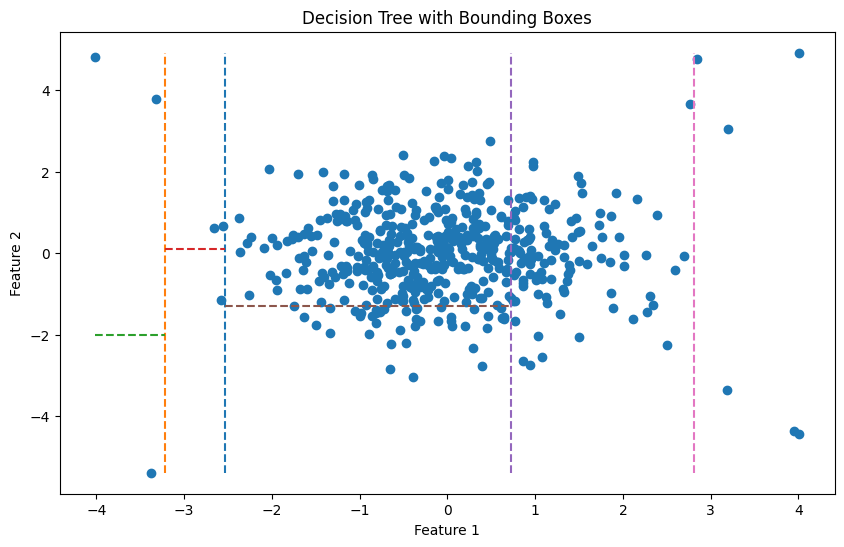

In [23]:
from utils import plot_tree_with_bboxes, BBox

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Decision Tree with Bounding Boxes")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.scatter(X[:, 0], X[:, 1])
plot_tree_with_bboxes(tree, BBox(X[:, 0].min(), X[:, 0].max(), X[:, 1].min(), X[:, 1].max()), ax)

And now we can define the function that will return the depth of the leaf where a point ends up.

In [ ]:
np.random.seed(0)  # for reproducibility

def get_depth(node, x):
    """
    Given a node and a point x, return the depth of the leaf where x ends up.
    """
    while not node.is_leaf:
        if x[node.feature] ...
            node = ...
        else:
            node = ...
    return node.depth


# we can construct a new tree and compute the depth of each sample
tree = build_tree(X, max_depth=6)

# now plot the depths of the samples
depths = np.array([get_depth(tree, x) for x in X])
plt.scatter(X[:, 0], X[:, 1], c=depths)
plt.colorbar(label="Corrected Depth")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Corrected Depth of Samples in Decision Tree")
plt.show()

In any case, a single isolation tree may not be a good enough estimator, so we will need to build a forest of isolation trees, named Isolation Forest by just creating an ensemble of isolation trees.

In [ ]:

def train_isolation_forest(X, n_trees, max_depth, max_samples):
    trees = []
    max_samples = min(max_samples, X.shape[0])
    for _ in trange(n_trees, desc="Training Trees"):
        # create a random sample of the data
        X_sampled_indices = ...
        # build a tree on the sample
        ...
    return trees, c(max_samples)

def predict_isolation_forest(trees, X, c_n):
    """
    Predict the anomaly score for each sample in X using the isolation forest.
    The anomaly score is the average depth of the leaf where the sample ends up in all trees.
    """
    depths = np.zeros((X.shape[0], len(trees)))
    for ...

    # compute the anomaly score with the formula
    scores = 2 ** (-avg_depths/c_n)  
            
    return scores

isolation_forest, c_n = train_isolation_forest(X, n_trees=100, max_depth=6, max_samples=256)
scores = predict_isolation_forest(isolation_forest, X, c_n)

plt.scatter(X[:, 0], X[:, 1], c=scores)
plt.colorbar(label="Anomaly Score")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Anomaly Scores from Isolation Forest")
plt.show()

## Piecewise Linear Regression (da primo appello 2024/2025)

In un reattore chimico, per ogni lotto si conoscono: 
- `temperatura` di reazione (°C)
- `tempo` di reazione (minuti)

L'obiettivo è costruire un modello di regressesione che, a partire dai valori di temperatura e tempo di reazione, faccia la predizione della resa del prodotto, cioè la `concentrazione` finale del prodotto (%).

Viene fornito un dataset storico con valori di temperatura e tempo di reazioni e le corrispondenti misurazioni reali di concentrazione. Sul dataset è già effettuato il pre-processing necessario. 

Provando un modello di regressione lineare, le performance non sono buone. 

Ci viene anche detto che il reattore **ha operato in 3 punti di lavoro diversi**.
È noto che **all'interno di ciascun punto di lavoro**, la relazione tra feature e target è **lineare**, tuttavia i **coefficienti sono diversi tra punti di lavoro diversi**. 

Vogliamo quindi un modello che catturi questi natura a tratti della relazione. Il modello, idealmente, avrà la forma: 
$$
g(x) = 
\begin{cases}
    f_0(x) & \text{se } x \text{ nel regime 0 } (k(x)=0) \\
    f_1(x) & \text{se } x \text{ nel regime 1 } (k(x)=1)\\
    f_2(x) & \text{se } x \text{ nel regime 2 } (k(x)=2)
\end{cases}
$$
dove: 
- $x$ è il vettore delle feature di un sample; 
- $f_i(x) = \beta_{0,i} + \beta_{1,i} x_1 + \beta_{2,i} x_2$ è il modello valido per il punto di lavoro $i$; 

<span style="color:red"><strong>NOTA IMPORTANTE</strong></span>: Il punto di lavoro a cui $x$ appartiente non ha una label esplicita, ma può essere **inferito dal dataset tramite clustering**.

<span style="color:red"><strong>TODO </strong></span>: 

- <span style="color:red"><strong>1</strong></span>: Implementa e usa **k-means** per raggruppare l'intero dataset X nei vari punti di lavoro. 
- <span style="color:red"><strong>2</strong></span>: Per ciascun punto di lavoro, costruisci un modello locale $f_i(x)$ valido sui dati provenienti da il corrispondente punto di lavoro. 
- <span style="color:red"><strong>3</strong></span>: **Combina** i modelli: costruisci il modello finale $g(x)$ che seleziona dinamicamente quale funzione $f_i(x)$ usare, in base al punto di lavoro a cui appartiene $x$.
- <span style="color:red"><strong>4</strong></span>: **Valutazione**: usando la tecnica più appropriata, confronta le performance del modello unico OLS del punto precedente $f(x)$ e del modello combinato $g(x)$. 

In [24]:
from utils_noexam import train_ols, predict_ols

In [25]:
data = pd.read_csv("ML_resources/chemical_reaction_data_exam.csv")
data = data.sample(n=900, random_state=0).reset_index(drop=True) 

# mostriamo le prime righe del dataset
display(data.head())  

X = data[['temperatura', 'tempo']].to_numpy()
y = data['concentrazione'].to_numpy()


,temperatura,tempo,concentrazione
0,32.715923,23.355512,43.982019
1,49.155693,35.612475,73.052034
2,26.330517,24.691696,38.776587
3,48.078821,36.804346,73.869210
4,68.542900,32.275001,59.583201


In [26]:
# K-means è sensibile all'iniziallizzazione dei centroidi. 
# Se vuoi, setta qui un seed per la riproducibilità. Se l'inizializzazione dei tuoi centroidi con questo seed non è buona, puoi cambiare il seed. 

np.random.seed(1)

In [ ]:
# Risposta 1:
def pairwise_distances(X, centroids): 
    """Returns the pairwise distance of each point in X with respect to each centroid.
    
    Args:
        X (np.ndarray): Data points of shape (n_samples, n_features).
        centroids (np.ndarray): Centroids of shape (n_centroids, n_features).
    """
    # distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2) # more efficient but less intuitive
    pairwise_distances = np.zeros((X.shape[0], centroids.shape[0]))
    for i in range(X.shape[0]): 
        for j in range(centroids.shape[0]): 
            pairwise_distances[i, j] = np.linalg.norm(X[i] - centroids[j])
    return pairwise_distances

class KMeansClustering: 
    def __init__(self, n_clusters:int, max_iters:int=100, tol:float=1e-6): 
        """
        Args:
            n_clusters: int - the number of clusters.
            max_iters: int - maximum number of iterations.
            tol: float - tolerance for convergence.
            random_state: int - seed for reproducibility.
        """
        self.k = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels_ = None         

    ...

    def fit(self, X): 
        ... 
        return self 
    

kmeans = KMeansClustering(n_clusters=3).fit(X)
fig = plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', marker='o', s=50)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# assumimo che kmean.labels_ contenga le etichette dei cluster assegnati a ciascun punto in X
# e che kmeans.k sia il numero di cluster


In [ ]:
# Risposte 2,3,4: 

# modifichiamo random_train_test_split in modo che torni anche la divisione dei cluster 
def random_train_test_split_modified(X, y, cluster_labels, proportion_train):
    split_point = int(
        proportion_train * X.shape[0]
    )  # numer of samples in the training set

    shuffled_indices = np.random.permutation(X.shape[0])

    train_indices = shuffled_indices[:split_point]
    test_indices = shuffled_indices[split_point:]

    X_train, y_train, cluster_train = X[train_indices], y[train_indices], cluster_labels[train_indices] # modifica
    X_test, y_test, cluster_test = X[test_indices], y[test_indices], cluster_labels[test_indices]       # modifica

    return X_train, X_test, y_train, y_test, cluster_train, cluster_test


k_fold = 10 
mses, r2s = [], []
for k in range(k_fold):
    # dividiamo in train e test set (anche le etichette dei cluster)
    X_train, X_test, y_train, y_test, cluster_train, cluster_test = random_train_test_split_modified(X, y, kmeans.labels_, proportion_train=0.8)

    mse_clusters, r2_clusters = [], []
    for i in range(kmeans.k): 
        X_train_cluster = X_train[cluster_train == i]
        y_train_cluster = y_train[cluster_train == i]
        X_test_cluster = X_test[cluster_test == i]
        y_test_cluster = y_test[cluster_test == i]

        # alleniamo un ols 
        beta_cluster = train_ols(X_train_cluster, y_train_cluster)
        y_pred_cluster = predict_ols(X_test_cluster, beta_cluster) 
        mse_cluster = np.mean((y_test_cluster - y_pred_cluster) ** 2)
        r2_cluster = 1 - np.sum((y_test_cluster - y_pred_cluster) ** 2) / np.sum((y_test_cluster - np.mean(y_test_cluster)) ** 2)
        mse_clusters.append(mse_cluster)
        r2_clusters.append(r2_cluster)
    
    # calcoliamo media di mse e r2 tra tutti e 3 i cluster
    mean_mse = np.mean(mse_clusters)
    mean_r2 = np.mean(r2_clusters)

    mses.append(mean_mse)
    r2s.append(mean_r2)

# boxplot degli MSE e R2
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot(mses)
plt.title("MSEs from Cross-Validation")
plt.xlabel("Mean Squared Error")
plt.subplot(1, 2, 2)
plt.boxplot(r2s)
plt.title("R2 Scores from Cross-Validation")
plt.xlabel("R2 Score")
plt.show()